# Notebook 01 — Analyse Exploratoire des Données (EDA)
## Challenge ENS #45 — Détection d'apnées du sommeil (Dreem)

---

## Vue d'ensemble

Ce notebook réalise une **analyse exploratoire complète** des données PSG brutes.
Il répond aux questions fondamentales qui guident l'architecture du notebook 03 :

| Question | Section | Conclusion |
|----------|---------|------------|
| Structure des données ? | §2 | (4400, 8, 9000) float32 |
| Quels signaux ? | §3 | 8 canaux PSG @ 100 Hz |
| Déséquilibre de classes ? | §5 | pos_weight ≈ 13.6 |
| Variabilité inter-sujets ? | §6 | ×37 entre min et max |
| À quoi ressemble une apnée ? | §7 | Chute AirFlow + désaturation SpO₂ (délai ~15-20 s) |
| Signaux discriminants ? | §8-9 | AirFlow, SpO₂, AbdoBelt, ThorBelt |
| Biais positionnels ? | §10 | Apnées uniformément distribuées dans la fenêtre |
| Corrélations entre canaux ? | §11 | AirFlow↔ThorBelt, AirFlow↔AbdoBelt corrélés |


---

## 1. Imports & configuration


In [12]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import h5py
from pathlib import Path
from scipy import signal as scipy_signal
from scipy.stats import pearsonr

plt.rcParams.update({'figure.dpi': 100, 'font.size': 10})

print(f'numpy   : {np.__version__}')
print(f'pandas  : {pd.__version__}')


numpy   : 2.4.4
pandas  : 3.0.2


In [13]:
# ── Chemins ──────────────────────────────────────────────────────────────────
DATA_DIR    = Path('../data/raw/')
FIGURES_DIR = Path('../figures/')
FIGURES_DIR.mkdir(exist_ok=True)

X_TRAIN_H5  = DATA_DIR / 'X_train.h5'
X_TEST_H5   = DATA_DIR / 'X_test.h5'
Y_TRAIN_CSV = DATA_DIR / 'y_train_tX9Br0C.csv'

print('Fichiers disponibles :')
for p in [X_TRAIN_H5, X_TEST_H5, Y_TRAIN_CSV]:
    print(f'  {p.name:40s}  {p.stat().st_size / 1e6:7.1f} Mo')


Fichiers disponibles :
  X_train.h5                                 1962.0 Mo
  X_test.h5                                  1977.4 Mo
  y_train_tX9Br0C.csv                           0.8 Mo


In [14]:
# ── Constantes ───────────────────────────────────────────────────────────────
SIGNAL_NAMES = [
    'AbdoBelt', 'AirFlow', 'PPG', 'ThorBelt',
    'Snoring', 'SpO2', 'EEG C4-A1', 'EEG O2-A1'
]
SIGNAL_COLORS = [
    '#2196F3', '#F44336', '#4CAF50', '#9C27B0',
    '#FF9800', '#00BCD4', '#795548', '#607D8B'
]
N_SIGNALS         = 8
N_SAMPLES         = 9000
N_LABEL_COLS      = 90
SIGNAL_FREQ       = 100
WINDOW_SECS       = 90
N_WINDOWS_PER_SUB = 200
VAL_SUBJECTS      = [0, 1, 8, 13, 15]
RANDOM_SEED       = 42
np.random.seed(RANDOM_SEED)


---

## 2. Chargement et exploration de la structure des données


In [15]:
# ── Exploration de la structure H5 ───────────────────────────────────────────
print('Structure du fichier H5 :')
with h5py.File(X_TRAIN_H5, 'r') as f:
    def print_h5(name, obj):
        indent = '  ' * name.count('/')
        if hasattr(obj, 'shape'):
            print(f'{indent}{name} : shape={obj.shape}  dtype={obj.dtype}')
        else:
            print(f'{indent}{name}/')
    f.visititems(print_h5)


Structure du fichier H5 :
data : shape=(4400, 72002)  dtype=float64


In [16]:
# ── Chargement complet ───────────────────────────────────────────────────────
print('Chargement des données ...')

def load_psg_tensor(path):
    with h5py.File(path, 'r') as f:
        key = list(f.keys())[0]
        raw = f[key][:].astype(np.float32)

    expected_width = 2 + N_SIGNALS * N_SAMPLES
    assert raw.shape[1] == expected_width, (
        f'Largeur inattendue pour {path.name}: {raw.shape[1]} (attendu {expected_width})'
    )

    window_ids = raw[:, 0].astype(np.int32)
    subject_ids = raw[:, 1].astype(np.int32)
    signals = raw[:, 2:].reshape(-1, N_SIGNALS, N_SAMPLES)
    return signals, window_ids, subject_ids, raw.shape

X_all, train_window_ids, subject_ids_from_h5, train_raw_shape = load_psg_tensor(X_TRAIN_H5)
X_test, test_window_ids, test_subject_ids, test_raw_shape = load_psg_tensor(X_TEST_H5)

df_labels  = pd.read_csv(Y_TRAIN_CSV)
label_cols = [f'y_{i}' for i in range(N_LABEL_COLS)]
Y_all      = df_labels[label_cols].values.astype(np.float32)  # (4400, 90)

N_SUBJECTS = X_all.shape[0] // N_WINDOWS_PER_SUB
subject_ids = np.arange(X_all.shape[0]) // N_WINDOWS_PER_SUB

assert np.array_equal(subject_ids_from_h5, subject_ids), 'subject_ids H5 incohérents avec le découpage attendu'
assert np.array_equal(train_window_ids, df_labels['ID'].to_numpy()), 'IDs H5 et CSV désalignés'

print(f'\n{"Variable":<20} {"Shape":<20} {"dtype":<10} {"Mémoire"}')
print('-' * 75)
for name, arr in [('X_all (train)', X_all), ('X_test', X_test), ('Y_all', Y_all)]:
    mem = arr.nbytes / 1e6
    print(f'{name:<20} {str(arr.shape):<20} {str(arr.dtype):<10} {mem:.1f} Mo')

print(f'\nShape brute train : {train_raw_shape} (col. 0 = ID fenêtre, col. 1 = ID sujet)')
print(f'Shape brute test  : {test_raw_shape}')
print(f'Nombre de sujets train : {N_SUBJECTS}')
print(f'Fenêtres par sujet     : {N_WINDOWS_PER_SUB}')


Chargement des données ...

Variable             Shape                dtype      Mémoire
---------------------------------------------------------------------------
X_all (train)        (4400, 8, 9000)      float32    1267.2 Mo
X_test               (4400, 8, 9000)      float32    1267.2 Mo
Y_all                (4400, 90)           float32    1.6 Mo

Shape brute train : (4400, 72002) (col. 0 = ID fenêtre, col. 1 = ID sujet)
Shape brute test  : (4400, 72002)
Nombre de sujets train : 22
Fenêtres par sujet     : 200


---

## 3. Description des 8 signaux PSG

Les signaux polysomnographiques (PSG) enregistrés par le casque Dreem couvrent
plusieurs modalités complémentaires pour la détection d'apnées :

| # | Signal | Unité | Rôle clinique | Signature apnée |
|---|--------|-------|---------------|-----------------|
| 0 | **AbdoBelt** | u.a. | Effort respiratoire abdominal | Oscillations persistent (effort compensatoire) |
| 1 | **AirFlow** | u.a. | Flux d'air nasal/buccal | **Chute brutale à zéro** |
| 2 | **PPG** | u.a. | Photopléthysmographie (Fc) | Irrégularités post-apnée |
| 3 | **ThorBelt** | u.a. | Effort respiratoire thoracique | Oscillations paradoxales |
| 4 | **Snoring** | u.a. | Microphone ronflement | Bruit juste avant l'apnée |
| 5 | **SpO₂** | % | Saturation en oxygène | **Désaturation (délai ~15-20 s)** |
| 6 | **EEG C4-A1** | µV | Activité cérébrale (centro-pariétal) | Micro-éveils en fin d'apnée |
| 7 | **EEG O2-A1** | µV | Activité cérébrale (occipital) | Micro-éveils en fin d'apnée |


---

## 4. Statistiques descriptives par canal


In [17]:
# ── Stats par canal ──────────────────────────────────────────────────────────
stats = []
for ch, name in enumerate(SIGNAL_NAMES):
    data = X_all[:, ch, :].ravel()
    stats.append({
        'Signal'  : name,
        'Moyenne' : data.mean(),
        'Std'     : data.std(),
        'Min'     : data.min(),
        'P1'      : np.percentile(data, 1),
        'P25'     : np.percentile(data, 25),
        'Médiane' : np.median(data),
        'P75'     : np.percentile(data, 75),
        'P99'     : np.percentile(data, 99),
        'Max'     : data.max(),
    })

df_stats = pd.DataFrame(stats).set_index('Signal')
print('Statistiques descriptives par canal :')
print(df_stats.round(3).to_string())


Statistiques descriptives par canal :
                Moyenne           Std          Min           P1           P25       Médiane           P75           P99            Max
Signal                                                                                                                                
AbdoBelt       5.888000    480.812988 -1145.484009 -1000.075012   -179.630005     -2.164000    208.977997   1000.075012    1181.553955
AirFlow      -28.403000     57.312000  -455.253998  -190.908005    -50.734001    -27.436001     -8.462000    139.824997     351.566986
PPG         -857.776001   1513.287964 -4995.012207 -3779.405029  -1815.449951  -1067.812988   -310.802002   3754.011963    4348.313965
ThorBelt      -9.013000    432.778992 -1187.902954 -1000.075012   -175.807999     -9.076000    162.298996   1000.075012    1183.392944
Snoring      693.812988    463.936005 -1171.444946  -391.981995    673.877014    896.054993    999.924988   1000.075012    1224.010010
SpO2       91942.

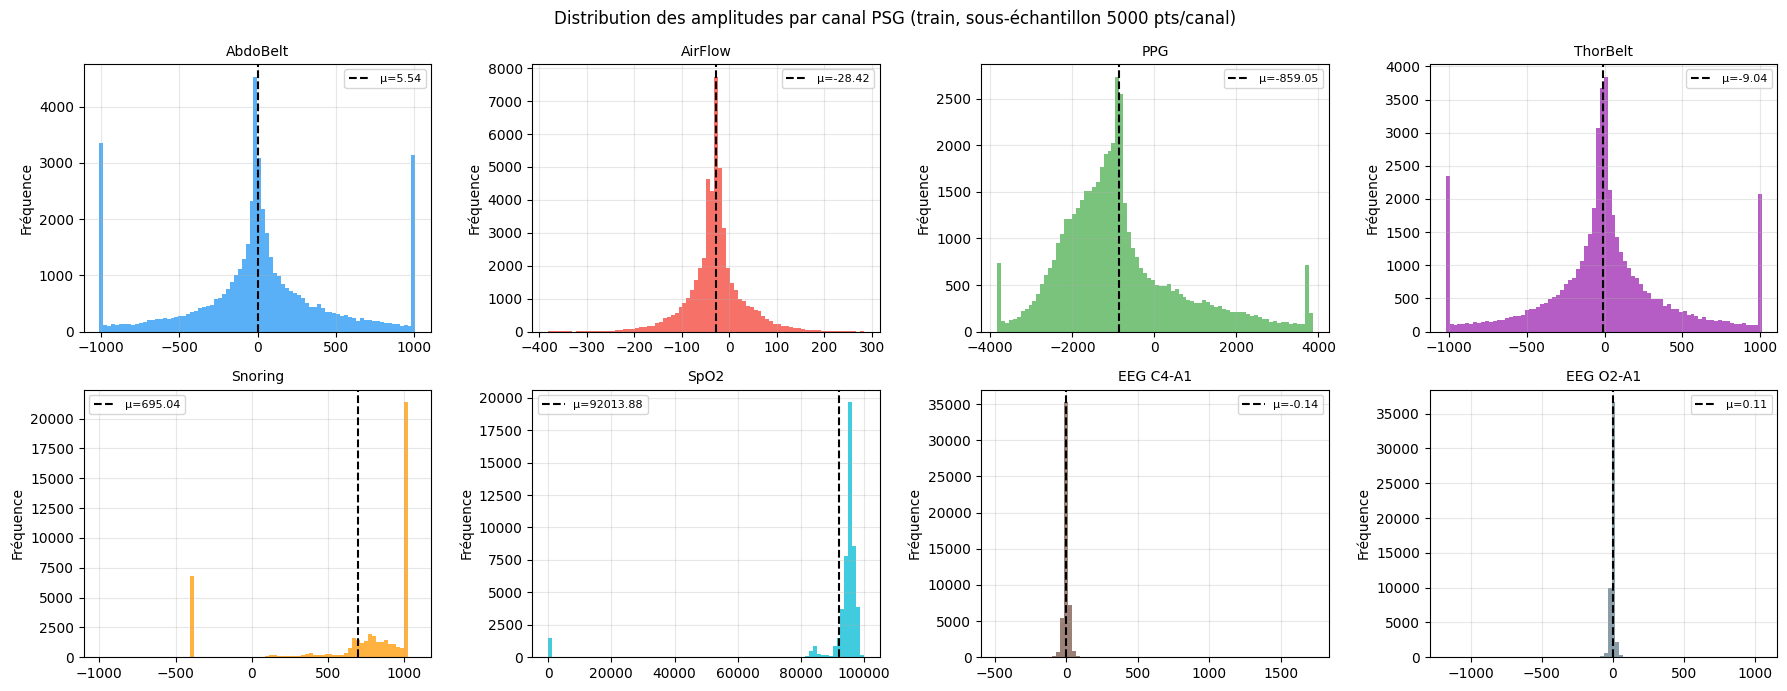

In [18]:
# ── Boxplots par canal ────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(18, 7))
fig.suptitle('Distribution des amplitudes par canal PSG (train, sous-échantillon 5000 pts/canal)',
             fontsize=12)

rng = np.random.default_rng(RANDOM_SEED)
for ch, (ax, name, color) in enumerate(zip(axes.ravel(), SIGNAL_NAMES, SIGNAL_COLORS)):
    data = X_all[:, ch, :].ravel()
    sample = rng.choice(data, size=min(50000, len(data)), replace=False)
    ax.hist(sample, bins=80, color=color, alpha=0.75, edgecolor='none')
    ax.axvline(sample.mean(), color='black', linewidth=1.5, linestyle='--',
               label=f'μ={sample.mean():.2f}')
    ax.set_title(f'{name}', fontsize=10)
    ax.set_ylabel('Fréquence')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig_01_signal_distributions.png', dpi=100, bbox_inches='tight')
plt.show()


---

## 5. Déséquilibre de classes

### Analyse globale


In [19]:
# ── Déséquilibre global ───────────────────────────────────────────────────────
total_sec  = Y_all.size
n_pos      = int(Y_all.sum())
n_neg      = total_sec - n_pos
rate_pct   = n_pos / total_sec * 100
pos_weight = n_neg / n_pos

print('='*55)
print('  DÉSÉQUILIBRE DE CLASSES — 22 sujets, 4400 fenêtres')
print('='*55)
print(f'  Secondes totales  : {total_sec:>10,}')
print(f'  Secondes apnée    : {n_pos:>10,}  ({rate_pct:.2f}%)')
print(f'  Secondes normales : {n_neg:>10,}  ({100-rate_pct:.2f}%)')
print(f'  Ratio N⁻/N⁺       : {pos_weight:.2f}')
print(f'  → pos_weight EDA (22 sujets) = {pos_weight:.2f}')
print(f'  → pos_weight split-train     ≈ 12.23  (calculé en notebook 02)')

apnea_per_window  = Y_all.sum(axis=1)
n_pos_windows     = (apnea_per_window > 0).sum()
n_neg_windows     = (apnea_per_window == 0).sum()
pct_pos_windows   = n_pos_windows / len(apnea_per_window) * 100
print(f'\n  Fenêtres avec ≥1 s apnée : {n_pos_windows} ({pct_pos_windows:.1f}%)')
print(f'  Fenêtres entièrement saines : {n_neg_windows} ({100-pct_pos_windows:.1f}%)')


  DÉSÉQUILIBRE DE CLASSES — 22 sujets, 4400 fenêtres
  Secondes totales  :    396,000
  Secondes apnée    :     27,214  (6.87%)
  Secondes normales :    368,786  (93.13%)
  Ratio N⁻/N⁺       : 13.55
  → pos_weight EDA (22 sujets) = 13.55
  → pos_weight split-train     ≈ 12.23  (calculé en notebook 02)

  Fenêtres avec ≥1 s apnée : 900 (20.5%)
  Fenêtres entièrement saines : 3500 (79.5%)


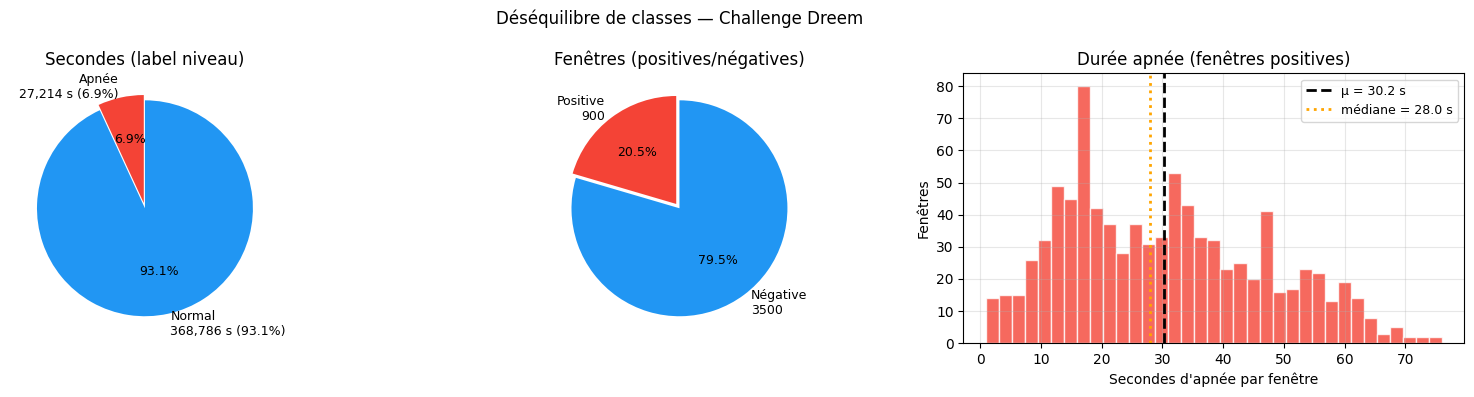

In [20]:
# ── Visualisation déséquilibre ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Déséquilibre de classes — Challenge Dreem", fontsize=12)

# 1. Camembert secondes
axes[0].pie([n_pos, n_neg],
            labels=[f'Apnée\n{n_pos:,} s ({rate_pct:.1f}%)',
                    f'Normal\n{n_neg:,} s ({100-rate_pct:.1f}%)'],
            colors=['#F44336', '#2196F3'], startangle=90,
            autopct='%1.1f%%', explode=(0.05, 0), textprops={'fontsize': 9})
axes[0].set_title('Secondes (label niveau)')

# 2. Camembert fenêtres
axes[1].pie([n_pos_windows, n_neg_windows],
            labels=[f'Positive\n{n_pos_windows}',
                    f'Négative\n{n_neg_windows}'],
            colors=['#F44336', '#2196F3'], startangle=90,
            autopct='%1.1f%%', explode=(0.05, 0), textprops={'fontsize': 9})
axes[1].set_title('Fenêtres (positives/négatives)')

# 3. Distribution secondes d'apnée par fenêtre positive
pos_wins = apnea_per_window[apnea_per_window > 0]
axes[2].hist(pos_wins, bins=35, color='#F44336', edgecolor='white', alpha=0.8)
axes[2].axvline(pos_wins.mean(), color='black', linestyle='--', linewidth=2,
                label=f'μ = {pos_wins.mean():.1f} s')
axes[2].axvline(np.median(pos_wins), color='orange', linestyle=':', linewidth=2,
                label=f'médiane = {np.median(pos_wins):.1f} s')
axes[2].set_xlabel("Secondes d'apnée par fenêtre")
axes[2].set_ylabel('Fenêtres')
axes[2].set_title('Durée apnée (fenêtres positives)')
axes[2].legend(fontsize=9)
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig_02_class_imbalance.png', dpi=100, bbox_inches='tight')
plt.show()


---

## 6. Analyse par sujet — variabilité inter-individuelle

La variabilité inter-sujets est l'un des défis majeurs du challenge. Le taux d'apnée
varie d'un facteur **×37** entre le sujet le plus léger et le plus sévère.
Cette hétérogénéité extrême justifie le split **par sujet** (pas aléatoire).


In [21]:
# ── Taux d'apnée par sujet ────────────────────────────────────────────────────
subject_stats = []
for s in range(N_SUBJECTS):
    mask = subject_ids == s
    y_sub = Y_all[mask]                     # (200, 90)
    n_pos_sub  = y_sub.sum()
    n_tot_sub  = y_sub.size
    rate       = y_sub.mean() * 100
    n_pos_win  = (y_sub.sum(axis=1) > 0).sum()
    split      = 'VAL' if s in VAL_SUBJECTS else 'TRAIN'
    subject_stats.append({
        'Sujet': s, 'Split': split,
        'Taux_apnée_%': round(rate, 2),
        'Fenêtres_pos': n_pos_win,
        'Secondes_apnée': int(n_pos_sub),
    })

df_sub = pd.DataFrame(subject_stats).set_index('Sujet')
print(df_sub.to_string())
print(f"\nMin  : {df_sub['Taux_apnée_%'].min():.2f}%  (sujet {df_sub['Taux_apnée_%'].idxmin()})")
print(f"Max  : {df_sub['Taux_apnée_%'].max():.2f}%  (sujet {df_sub['Taux_apnée_%'].idxmax()})")
print(f"Moy  : {df_sub['Taux_apnée_%'].mean():.2f}%")
print(f"Ratio max/min : {df_sub['Taux_apnée_%'].max() / df_sub['Taux_apnée_%'].min():.1f}×")


       Split  Taux_apnée_%  Fenêtres_pos  Secondes_apnée
Sujet                                                   
0        VAL      0.990000            10             178
1        VAL      2.900000            15             522
2      TRAIN      9.560000            64            1721
3      TRAIN      7.970000            55            1434
4      TRAIN     27.240000           116            4903
5      TRAIN      7.970000            45            1434
6      TRAIN      5.750000            41            1035
7      TRAIN      6.950000            48            1251
8        VAL     13.770000            78            2479
9      TRAIN      1.130000            16             203
10     TRAIN     10.310000            49            1855
11     TRAIN      2.120000            16             381
12     TRAIN     12.180000            76            2193
13       VAL      1.630000            15             294
14     TRAIN      1.150000            11             207
15       VAL      3.410000     

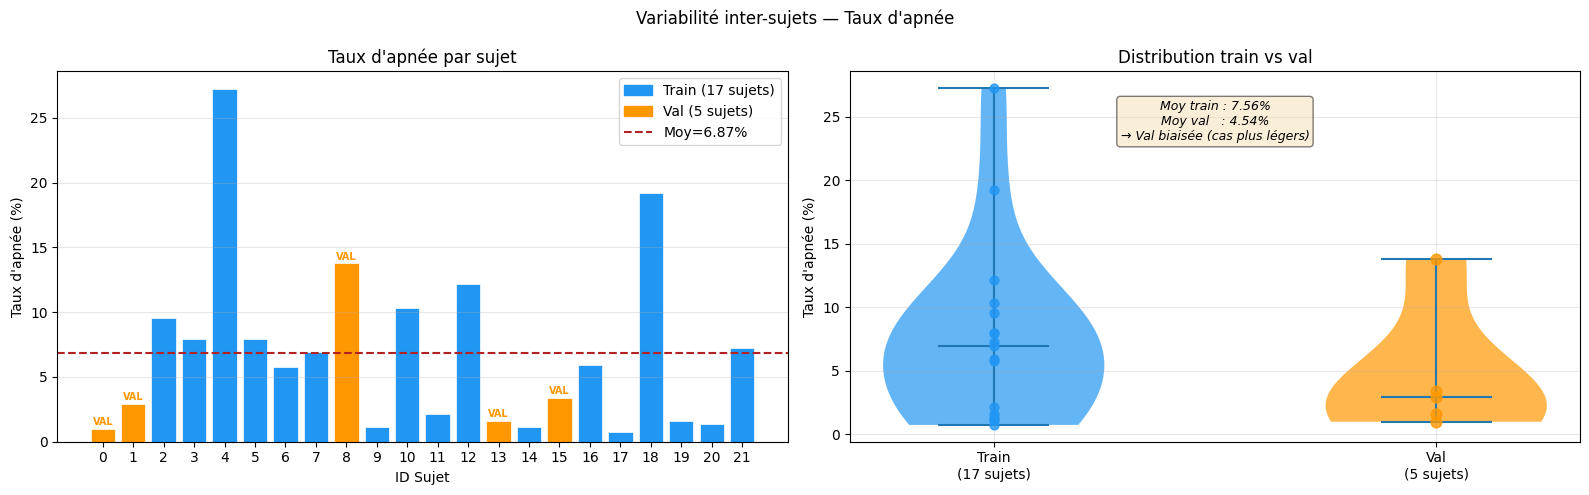

In [22]:
# ── Graphique par sujet ───────────────────────────────────────────────────────
rates = df_sub['Taux_apnée_%'].values
splits = df_sub['Split'].values
colors = ['#FF9800' if s == 'VAL' else '#2196F3' for s in splits]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Variabilité inter-sujets — Taux d\'apnée', fontsize=12)

# Barplot
ax = axes[0]
bars = ax.bar(range(N_SUBJECTS), rates, color=colors, edgecolor='white', linewidth=0.5)
ax.axhline(rates.mean(), color='firebrick', linestyle='--', linewidth=1.5,
           label=f'Moyenne = {rates.mean():.2f}%')
# Annotation val subjects
for s in VAL_SUBJECTS:
    ax.text(s, rates[s] + 0.3, 'VAL', ha='center', fontsize=7, color='#FF9800', fontweight='bold')
ax.set_xlabel('ID Sujet')
ax.set_ylabel("Taux d'apnée (%)")
ax.set_title('Taux d\'apnée par sujet')
ax.set_xticks(range(N_SUBJECTS))
train_p = mpatches.Patch(color='#2196F3', label='Train (17 sujets)')
val_p   = mpatches.Patch(color='#FF9800', label='Val (5 sujets)')
ax.legend(handles=[train_p, val_p,
                   plt.Line2D([],[],color='firebrick',linestyle='--',
                              label=f'Moy={rates.mean():.2f}%')])
ax.grid(axis='y', alpha=0.3)

# Distribution en violon
ax2 = axes[1]
train_rates = rates[[s for s in range(N_SUBJECTS) if s not in VAL_SUBJECTS]]
val_rates   = rates[VAL_SUBJECTS]
vp = ax2.violinplot([train_rates, val_rates], positions=[1, 2], showmedians=True)
for pc, c in zip(vp['bodies'], ['#2196F3', '#FF9800']):
    pc.set_facecolor(c); pc.set_alpha(0.7)
ax2.scatter([1]*len(train_rates), train_rates, color='#2196F3', alpha=0.8, zorder=3, s=40)
ax2.scatter([2]*len(val_rates),   val_rates,   color='#FF9800', alpha=0.8, zorder=3, s=60)
ax2.set_xticks([1, 2])
ax2.set_xticklabels(['Train\n(17 sujets)', 'Val\n(5 sujets)'])
ax2.set_ylabel("Taux d'apnée (%)")
ax2.set_title('Distribution train vs val')
ax2.grid(alpha=0.3)
# Note biais
ax2.text(1.5, max(rates)*0.85,
         f'Moy train : {train_rates.mean():.2f}%\nMoy val   : {val_rates.mean():.2f}%\n→ Val biaisée (cas plus légers)',
         ha='center', fontsize=9, style='italic',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig_03_subject_variability.png', dpi=100, bbox_inches='tight')
plt.show()


---

## 7. Visualisation d'exemples d'apnées — les 8 canaux

On sélectionne 3 fenêtres représentatives : apnée sévère, apnée modérée, fenêtre saine.


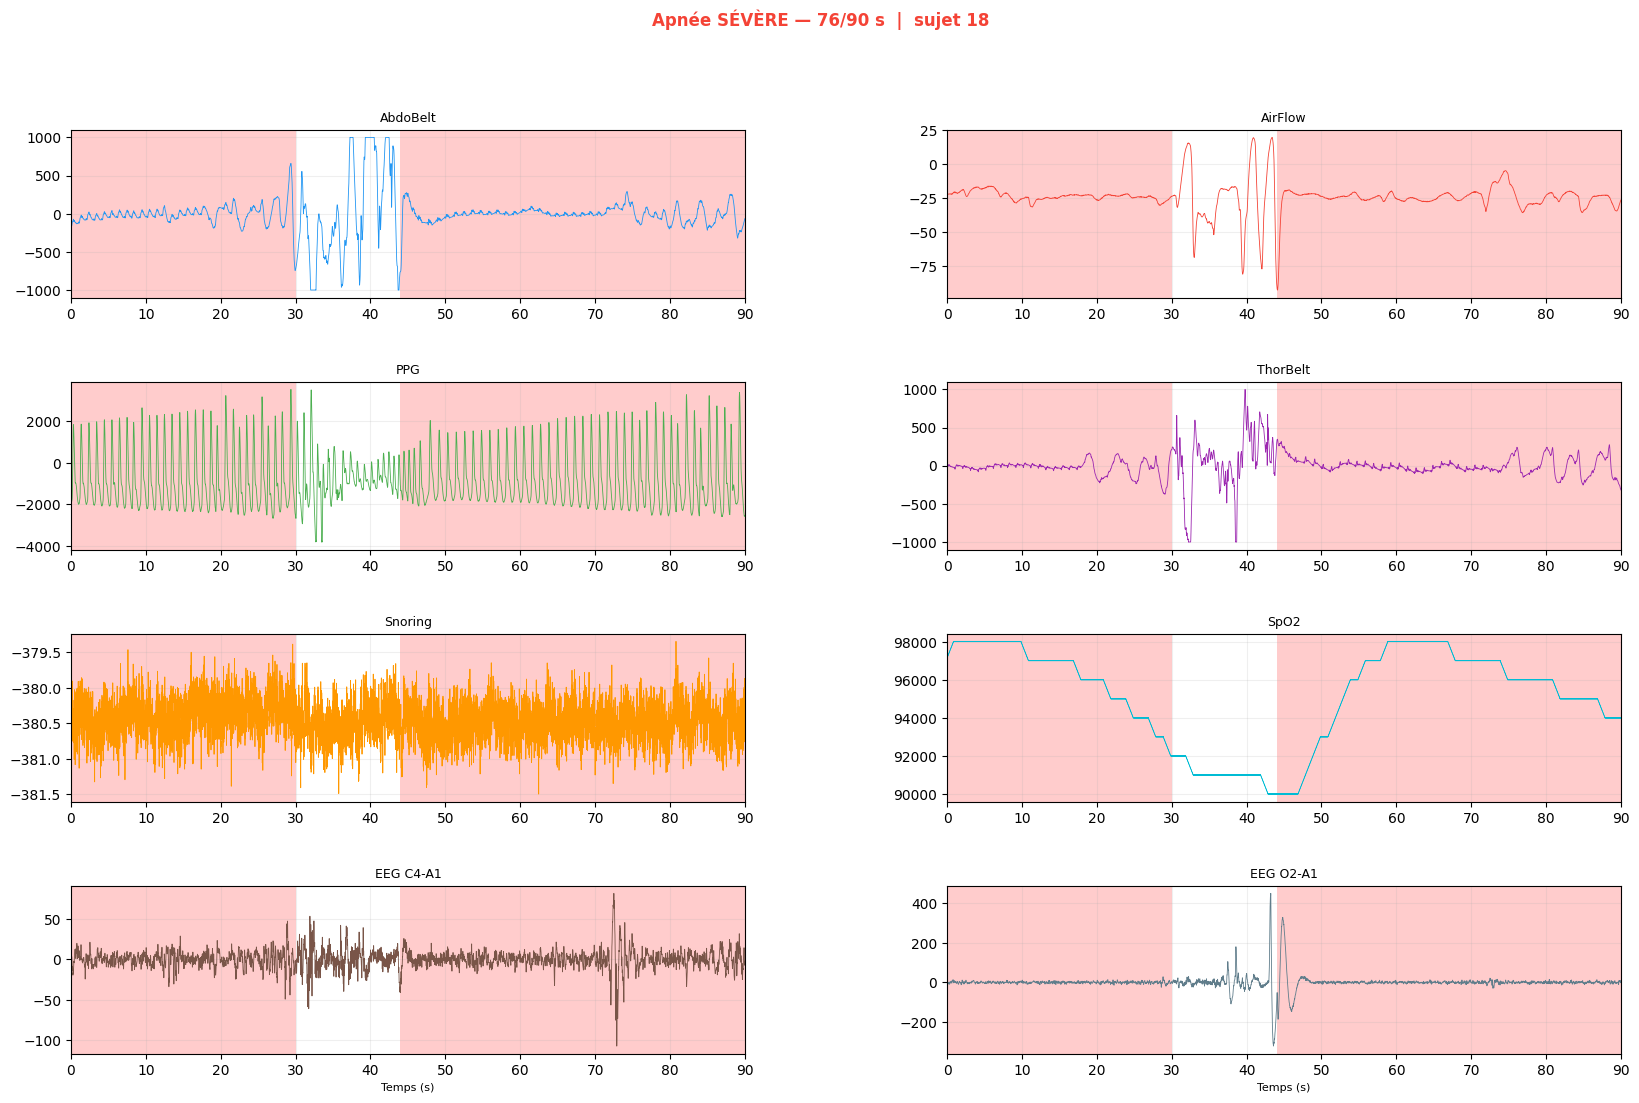

Sujet 18 | taux d'apnée sujet = 19.21%


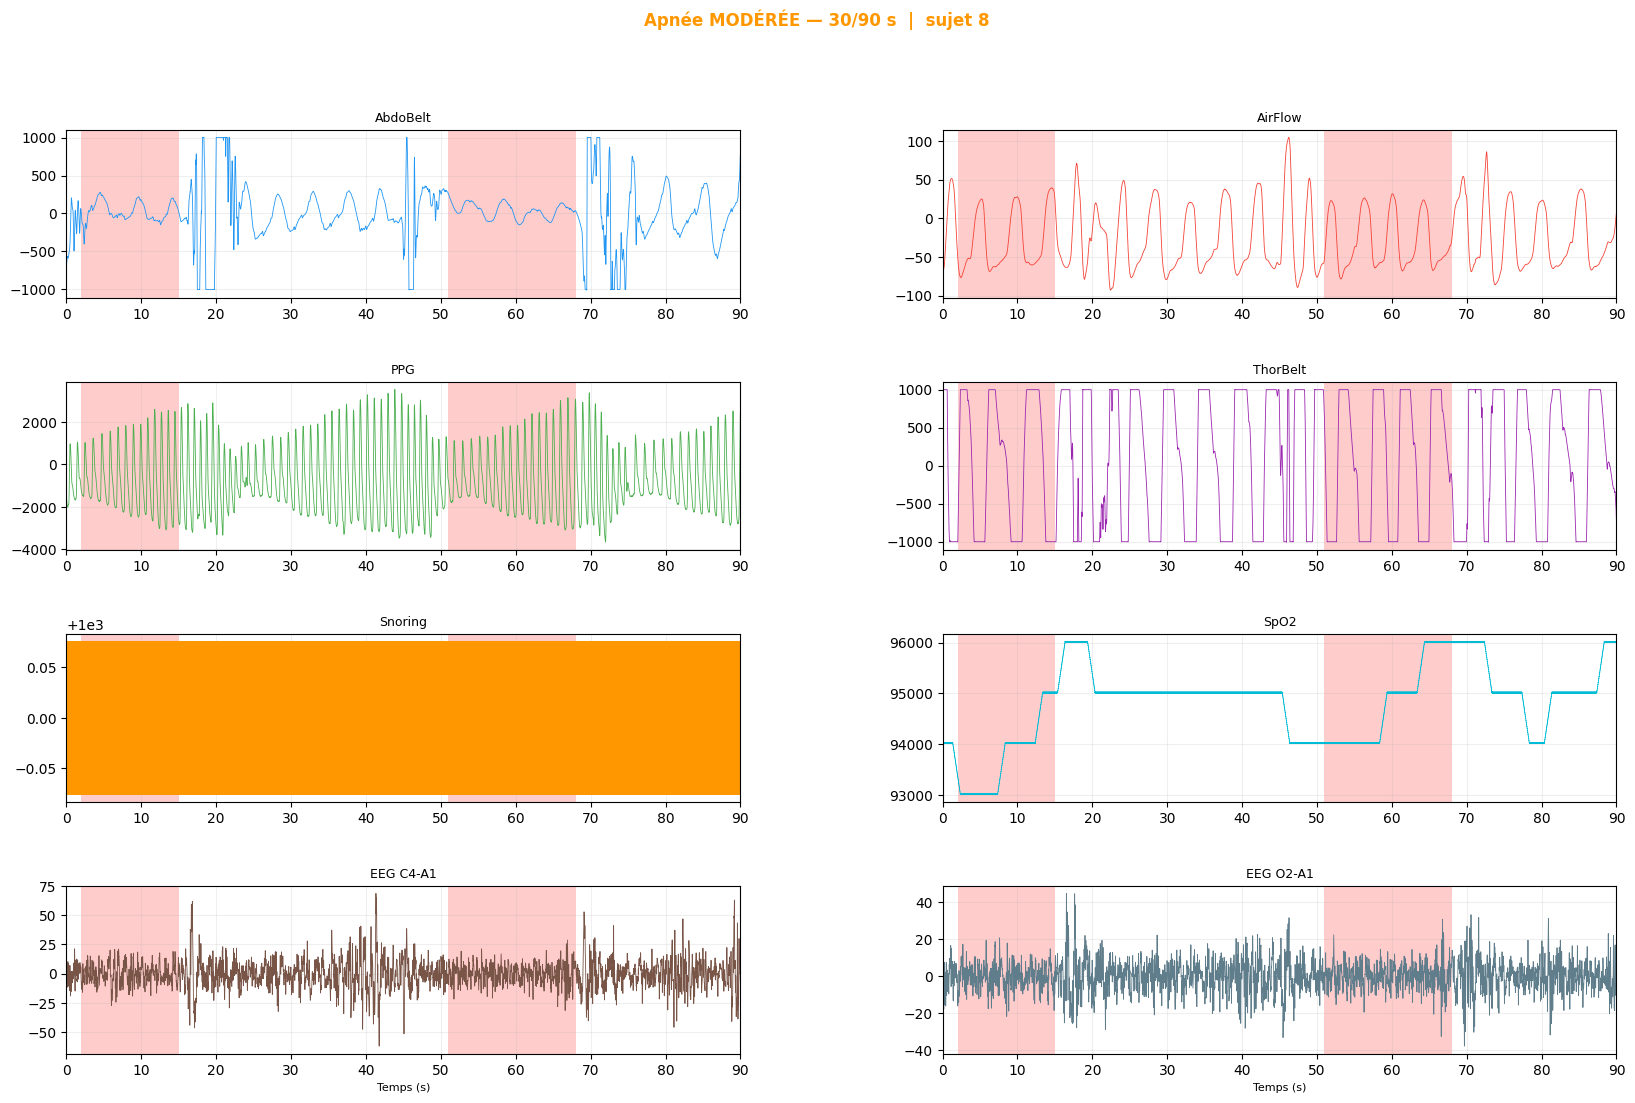

Sujet 8 | taux d'apnée sujet = 13.77%


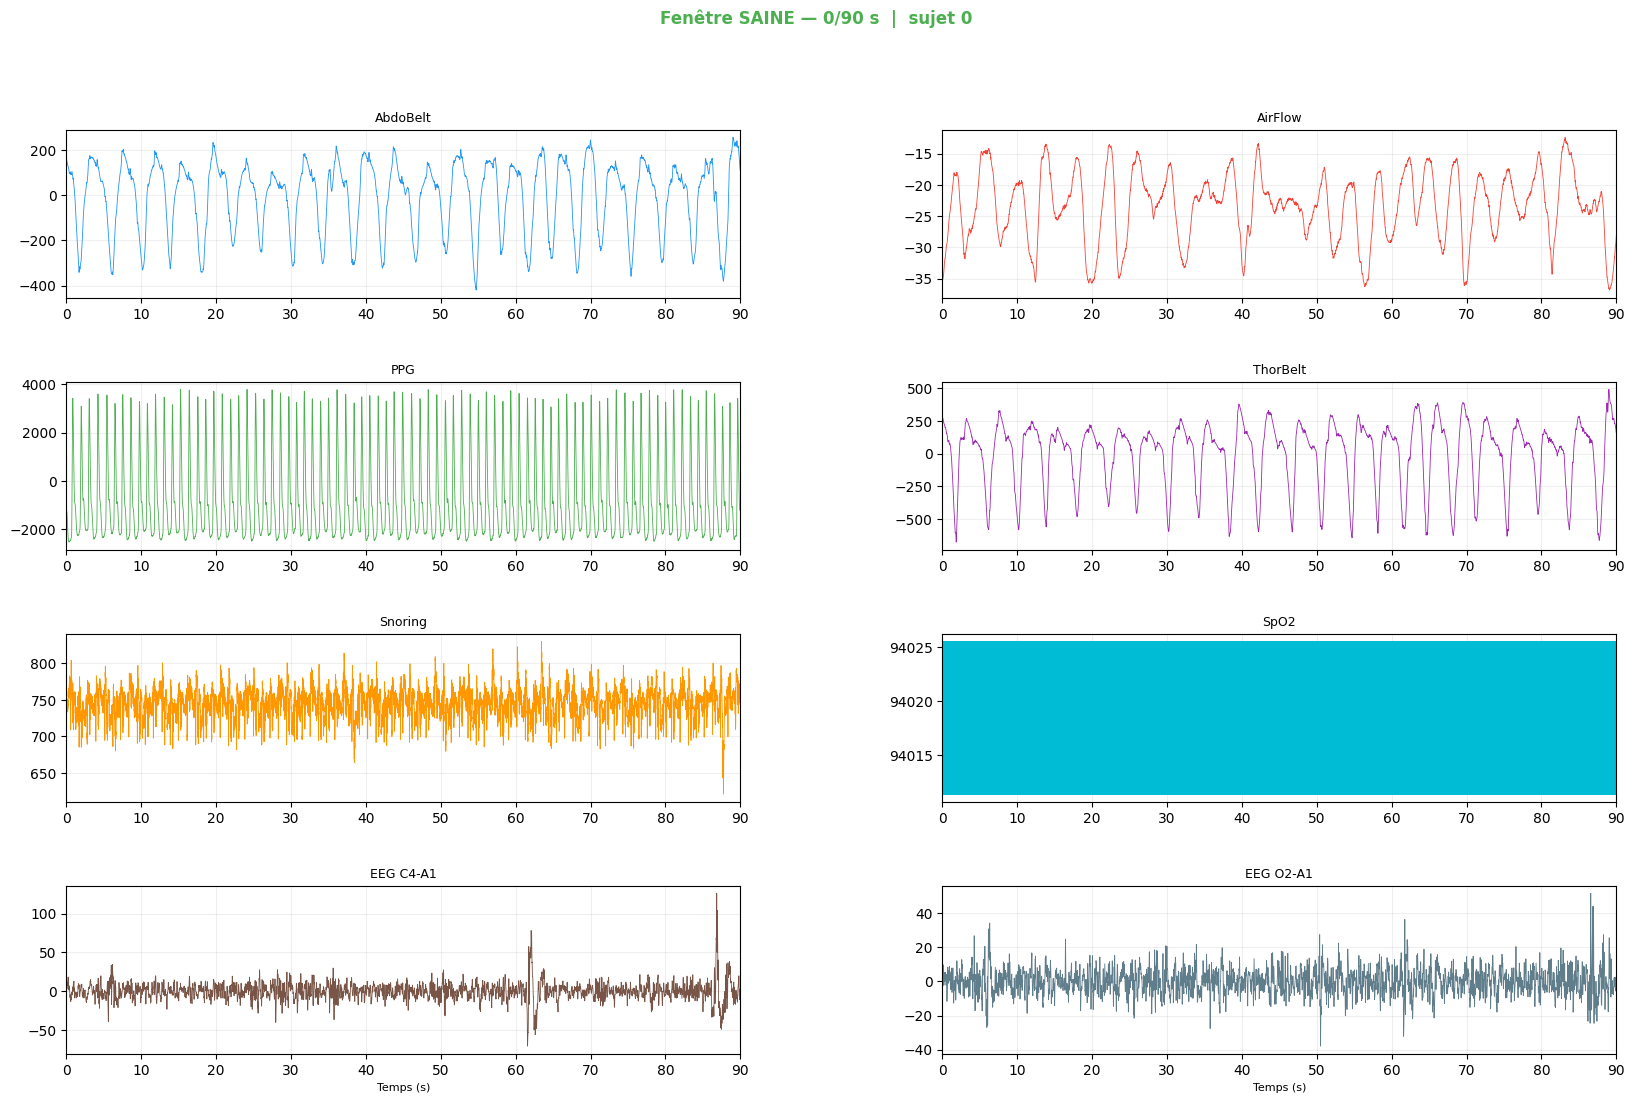

Sujet 0 | taux d'apnée sujet = 0.99%


In [23]:
# ── Sélection de 3 exemples représentatifs ────────────────────────────────────
apnea_per_window = Y_all.sum(axis=1)

# Apnée sévère : fenêtre avec le plus de secondes d'apnée
idx_severe  = np.argmax(apnea_per_window)
# Apnée modérée : fenêtre avec ~20-30 s d'apnée
mod_cands   = np.where((apnea_per_window >= 20) & (apnea_per_window <= 30))[0]
idx_moderate = mod_cands[len(mod_cands)//2] if len(mod_cands) > 0 else np.argsort(apnea_per_window)[len(apnea_per_window)//2]
# Fenêtre saine
idx_healthy  = np.where(apnea_per_window == 0)[0][10]

examples = [
    (idx_severe,   f'Apnée SÉVÈRE — {int(apnea_per_window[idx_severe])}/90 s',   '#F44336'),
    (idx_moderate, f'Apnée MODÉRÉE — {int(apnea_per_window[idx_moderate])}/90 s', '#FF9800'),
    (idx_healthy,  'Fenêtre SAINE — 0/90 s',                                       '#4CAF50'),
]

time_sig = np.arange(N_SAMPLES) / SIGNAL_FREQ

for win_idx, title, title_color in examples:
    x_ex = X_all[win_idx]      # (8, 9000)
    y_ex = Y_all[win_idx]      # (90,)

    fig = plt.figure(figsize=(20, 12))
    fig.suptitle(f'{title}  |  sujet {subject_ids[win_idx]}', fontsize=12,
                 color=title_color, fontweight='bold')
    gs = gridspec.GridSpec(4, 2, figure=fig, hspace=0.5, wspace=0.3)

    for ch in range(N_SIGNALS):
        ax = fig.add_subplot(gs[ch // 2, ch % 2])
        ax.plot(time_sig, x_ex[ch], color=SIGNAL_COLORS[ch], linewidth=0.6)
        # Zones apnée
        for s in range(N_LABEL_COLS):
            if y_ex[s] == 1:
                ax.axvspan(s, s+1, color='red', alpha=0.2, linewidth=0)
        ax.set_title(SIGNAL_NAMES[ch], fontsize=9)
        ax.set_xlim(0, WINDOW_SECS)
        ax.grid(alpha=0.2)
        if ch >= 6: ax.set_xlabel('Temps (s)', fontsize=8)

    safe_title = title.split(' — ')[0].replace(' ', '_')
    plt.savefig(FIGURES_DIR / f'fig_example_{safe_title}.png', dpi=90, bbox_inches='tight')
    plt.show()
    print(f'Sujet {subject_ids[win_idx]} | taux d\'apnée sujet = {df_sub.loc[subject_ids[win_idx], "Taux_apnée_%"]:.2f}%')


---

## 8. Comparaison signal normal vs apnée par canal

On compare la distribution des amplitudes **pendant** et **hors** apnée
pour identifier les canaux les plus discriminants.


In [24]:
# ── Segmentation des secondes : apnée vs normal ───────────────────────────────
# Y_all : (4400, 90) → on extrait les signaux par seconde
# Pour chaque seconde on prend la moyenne sur les 100 échantillons

print('Construction des matrices signal-par-seconde ...')
# X_sec : (4400, 90, 8) — moyenne par seconde par canal
X_sec = X_all.reshape(4400, 8, 90, 100).mean(axis=-1)  # (4400, 8, 90)
X_sec = X_sec.transpose(0, 2, 1)                        # (4400, 90, 8)

y_flat = Y_all.ravel().astype(bool)           # (4400*90,)
X_flat = X_sec.reshape(-1, N_SIGNALS)          # (4400*90, 8)

n_sample = 30000   # sous-échantillon pour la vitesse
rng = np.random.default_rng(RANDOM_SEED)

pos_idx = np.where(y_flat)[0]
neg_idx = np.where(~y_flat)[0]
pos_sample = rng.choice(pos_idx, size=min(n_sample, len(pos_idx)), replace=False)
neg_sample = rng.choice(neg_idx, size=min(n_sample, len(neg_idx)), replace=False)

X_pos = X_flat[pos_sample]   # secondes apnée
X_neg = X_flat[neg_sample]   # secondes normales
print(f'Secondes apnée   : {len(X_pos):,}')
print(f'Secondes normales: {len(X_neg):,}')


Construction des matrices signal-par-seconde ...
Secondes apnée   : 27,214
Secondes normales: 30,000


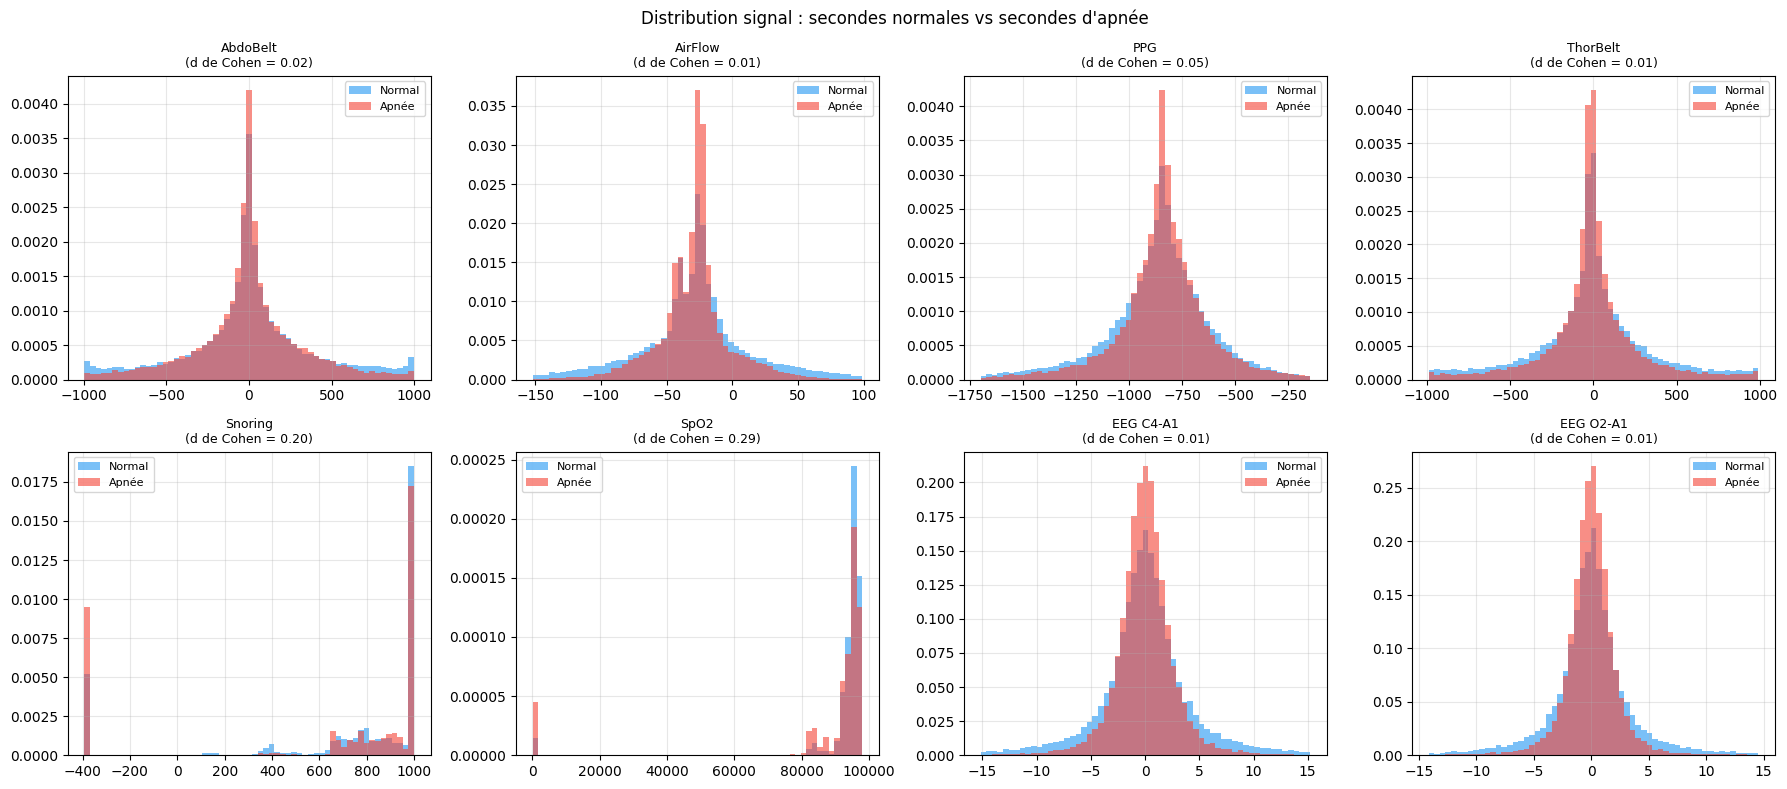

d de Cohen > 0.5 = bon pouvoir discriminant


In [25]:
# ── Overlapping histogrammes apnée vs normal ──────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('Distribution signal : secondes normales vs secondes d\'apnée', fontsize=12)

for ch, (ax, name) in enumerate(zip(axes.ravel(), SIGNAL_NAMES)):
    vmin = np.percentile(np.concatenate([X_pos[:,ch], X_neg[:,ch]]), 1)
    vmax = np.percentile(np.concatenate([X_pos[:,ch], X_neg[:,ch]]), 99)
    bins = np.linspace(vmin, vmax, 60)

    ax.hist(X_neg[:,ch], bins=bins, color='#2196F3', alpha=0.6, density=True, label='Normal')
    ax.hist(X_pos[:,ch], bins=bins, color='#F44336', alpha=0.6, density=True, label='Apnée')

    # Séparabilité : distance de Bhattacharyya approx = diff de moyennes / std poolée
    mu_diff = abs(X_pos[:,ch].mean() - X_neg[:,ch].mean())
    s_pool  = np.sqrt((X_pos[:,ch].var() + X_neg[:,ch].var()) / 2)
    d_cohen = mu_diff / s_pool if s_pool > 0 else 0

    ax.set_title(f'{name}\n(d de Cohen = {d_cohen:.2f})', fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig_04_apnea_vs_normal.png', dpi=100, bbox_inches='tight')
plt.show()
print('d de Cohen > 0.5 = bon pouvoir discriminant')


---

## 9. Analyse spectrale — contenu fréquentiel par canal

L'analyse de Fourier révèle si les canaux PSG ont un contenu fréquentiel
différent pendant et hors apnée — information utile pour choisir la taille des kernels CNN.


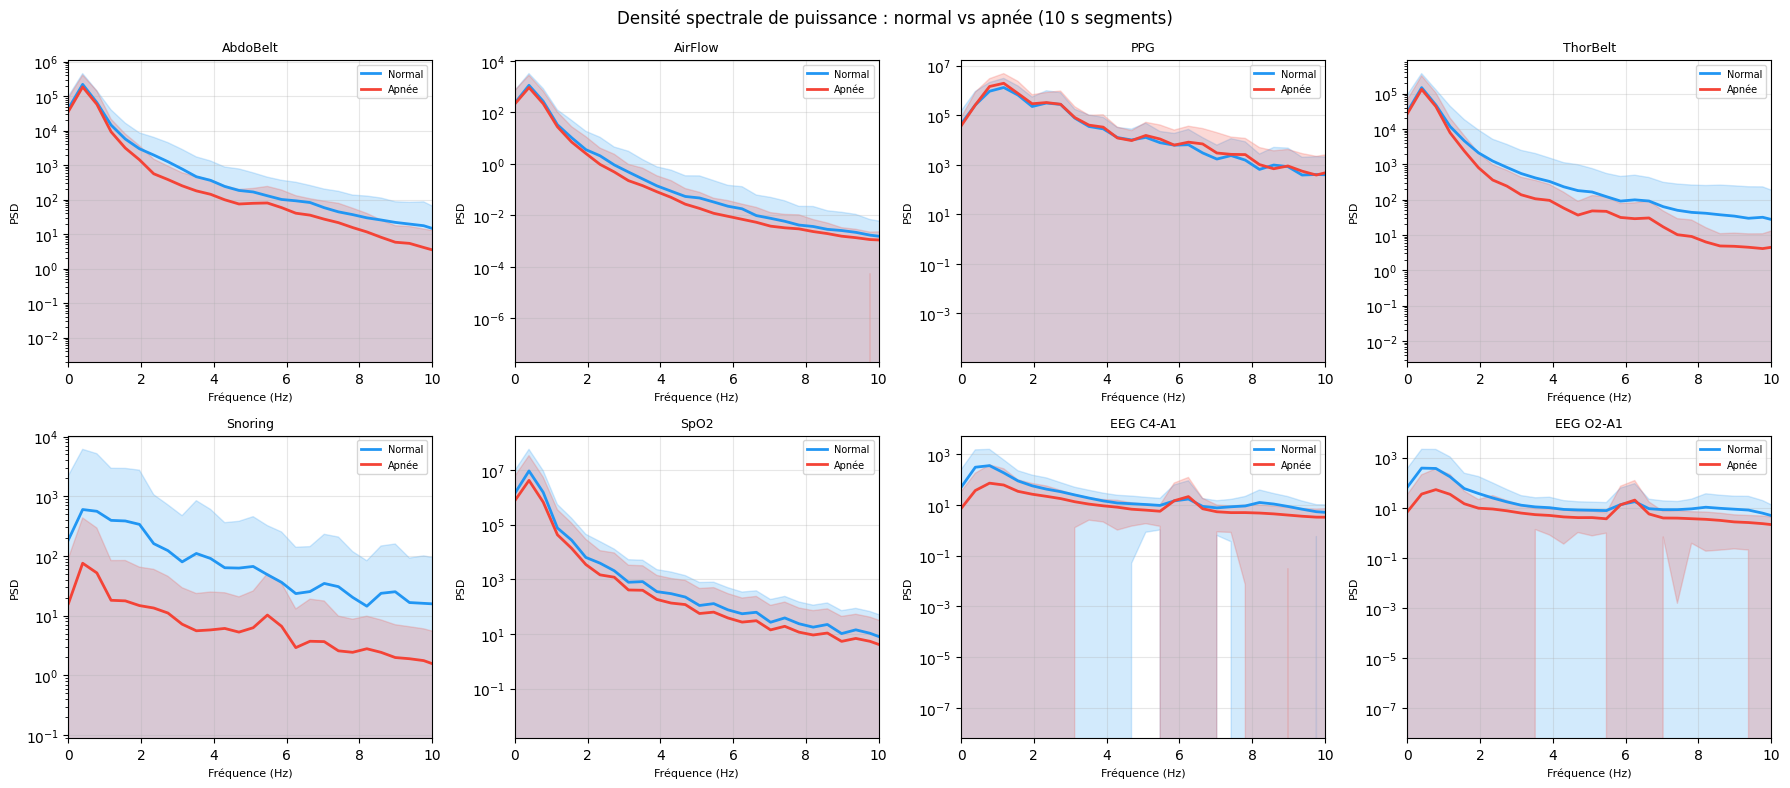

In [26]:
# ── PSD (Power Spectral Density) : apnée vs normal ───────────────────────────
# On prend des segments de 1000 points (10 s) annotés apnée et normal
SEGMENT_LEN = 1000   # 10 secondes

psd_pos = {ch: [] for ch in range(N_SIGNALS)}
psd_neg = {ch: [] for ch in range(N_SIGNALS)}

rng2 = np.random.default_rng(RANDOM_SEED + 1)
n_seg = 200

for win_i in rng2.choice(len(X_all), size=min(500, len(X_all)), replace=False):
    y_win = Y_all[win_i]    # (90,)
    for start_s in range(0, 80, 10):    # fenêtres de 10 s
        label = int(y_win[start_s:start_s+10].mean() > 0.5)
        seg   = X_all[win_i, :, start_s*100:(start_s+10)*100]  # (8, 1000)
        for ch in range(N_SIGNALS):
            f, pxx = scipy_signal.welch(seg[ch], fs=SIGNAL_FREQ, nperseg=256)
            if label == 1 and len(psd_pos[ch]) < n_seg:
                psd_pos[ch].append(pxx)
            elif label == 0 and len(psd_neg[ch]) < n_seg:
                psd_neg[ch].append(pxx)

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('Densité spectrale de puissance : normal vs apnée (10 s segments)', fontsize=12)

for ch, (ax, name, color) in enumerate(zip(axes.ravel(), SIGNAL_NAMES, SIGNAL_COLORS)):
    if psd_pos[ch] and psd_neg[ch]:
        pxx_pos_m = np.array(psd_pos[ch]).mean(axis=0)
        pxx_neg_m = np.array(psd_neg[ch]).mean(axis=0)
        pxx_pos_s = np.array(psd_pos[ch]).std(axis=0)
        pxx_neg_s = np.array(psd_neg[ch]).std(axis=0)
        ax.semilogy(f, pxx_neg_m, color='#2196F3', linewidth=2, label='Normal')
        ax.fill_between(f, pxx_neg_m-pxx_neg_s, pxx_neg_m+pxx_neg_s, color='#2196F3', alpha=0.2)
        ax.semilogy(f, pxx_pos_m, color='#F44336', linewidth=2, label='Apnée')
        ax.fill_between(f, pxx_pos_m-pxx_pos_s, pxx_pos_m+pxx_pos_s, color='#F44336', alpha=0.2)
    ax.set_title(name, fontsize=9)
    ax.set_xlabel('Fréquence (Hz)', fontsize=8)
    ax.set_ylabel('PSD', fontsize=8)
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)
    ax.set_xlim(0, 10)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig_05_spectral_analysis.png', dpi=100, bbox_inches='tight')
plt.show()


---

## 10. Délai AirFlow → SpO₂ et cross-corrélation

Une caractéristique clé de l'apnée : la chute du flux nasal (AirFlow) précède
la désaturation (SpO₂) d'environ **15-20 secondes** (temps de circulation sanguine).
Ce délai justifie l'utilisation du BiLSTM pour capturer les dépendances temporelles longues.


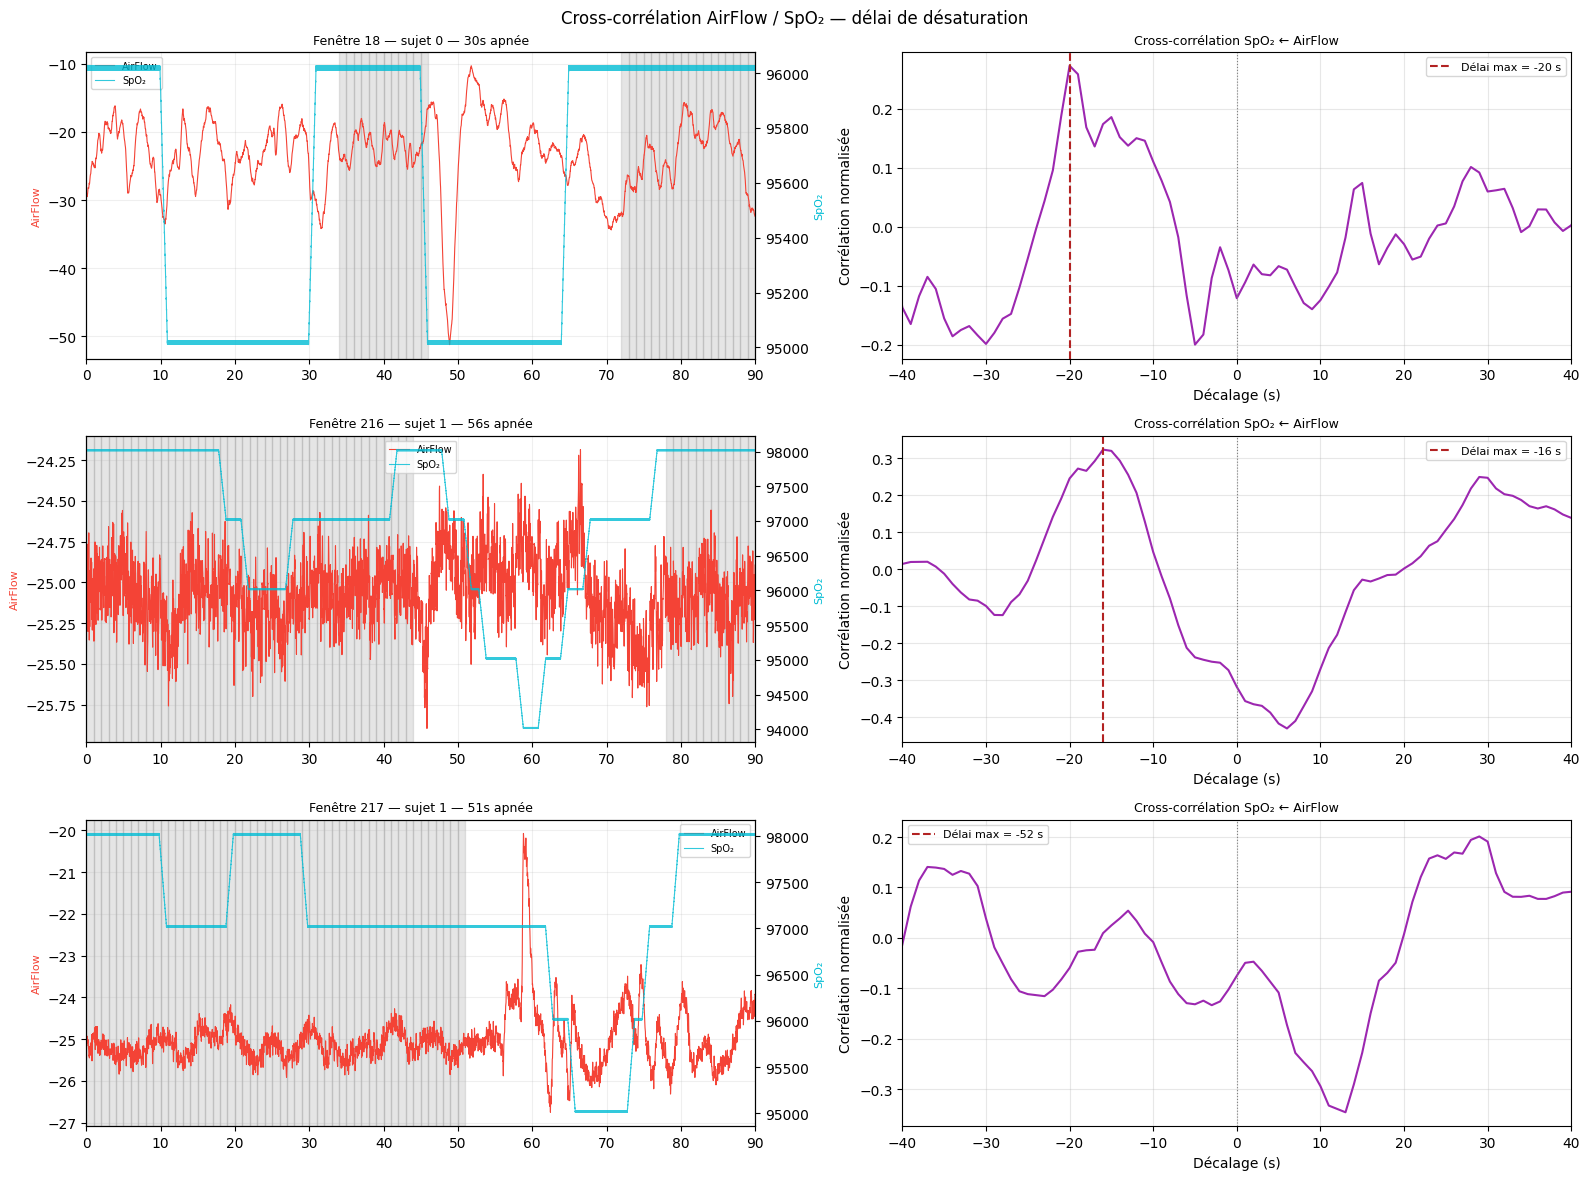

Délais mesurés : [np.int64(-20), np.int64(-16), np.int64(-52)] s
Délai moyen : -29.3 s (typiquement 15-20 s en clinique)


In [27]:
# ── Cross-corrélation AirFlow / SpO₂ sur exemples avec apnée ─────────────────
AIRFLOW_IDX = SIGNAL_NAMES.index('AirFlow')   # 1
SPO2_IDX    = SIGNAL_NAMES.index('SpO2')       # 5

# Sélectionner des fenêtres avec apnée modérée-sévère
heavy_apnea = np.where(apnea_per_window >= 30)[0]
delays_found = []

fig, axes = plt.subplots(3, 2, figsize=(16, 12))
fig.suptitle('Cross-corrélation AirFlow / SpO₂ — délai de désaturation', fontsize=12)

for i, win_i in enumerate(heavy_apnea[:3]):
    air  = X_all[win_i, AIRFLOW_IDX, :]   # (9000,)
    spo2 = X_all[win_i, SPO2_IDX, :]      # (9000,)
    y_ex = Y_all[win_i]
    time_sig = np.arange(N_SAMPLES) / SIGNAL_FREQ

    # Signaux
    ax_sig = axes[i, 0]
    ax2_sig = ax_sig.twinx()
    ax_sig.plot(time_sig, air,  color='#F44336', linewidth=0.8, label='AirFlow')
    ax2_sig.plot(time_sig, spo2, color='#00BCD4', linewidth=0.8, label='SpO₂', alpha=0.8)
    for s in range(N_LABEL_COLS):
        if y_ex[s]: ax_sig.axvspan(s, s+1, color='gray', alpha=0.2)
    ax_sig.set_xlim(0, WINDOW_SECS)
    ax_sig.set_ylabel('AirFlow', color='#F44336', fontsize=8)
    ax2_sig.set_ylabel('SpO₂', color='#00BCD4', fontsize=8)
    ax_sig.set_title(f'Fenêtre {win_i} — sujet {subject_ids[win_i]} — {int(apnea_per_window[win_i])}s apnée', fontsize=9)
    ax_sig.grid(alpha=0.2)
    lines1, labs1 = ax_sig.get_legend_handles_labels()
    lines2, labs2 = ax2_sig.get_legend_handles_labels()
    ax_sig.legend(lines1+lines2, labs1+labs2, fontsize=7)

    # Cross-corrélation (rééchantillonné à 1 Hz pour lisibilité)
    ax_cc = axes[i, 1]
    air_1hz  = air.reshape(WINDOW_SECS, 100).mean(axis=1)
    spo2_1hz = spo2.reshape(WINDOW_SECS, 100).mean(axis=1)
    # Normalisation
    air_n  = (air_1hz  - air_1hz.mean())  / (air_1hz.std()  + 1e-8)
    spo2_n = (spo2_1hz - spo2_1hz.mean()) / (spo2_1hz.std() + 1e-8)
    xcorr  = np.correlate(spo2_n, air_n, mode='full')
    xcorr /= WINDOW_SECS
    lags   = np.arange(-WINDOW_SECS+1, WINDOW_SECS)
    best_lag = lags[np.argmax(xcorr)]
    delays_found.append(best_lag)

    ax_cc.plot(lags, xcorr, color='#9C27B0', linewidth=1.5)
    ax_cc.axvline(best_lag, color='firebrick', linestyle='--',
                  label=f'Délai max = {best_lag} s')
    ax_cc.axvline(0, color='gray', linestyle=':', linewidth=0.8)
    ax_cc.set_xlabel('Décalage (s)')
    ax_cc.set_ylabel('Corrélation normalisée')
    ax_cc.set_title(f'Cross-corrélation SpO₂ ← AirFlow', fontsize=9)
    ax_cc.legend(fontsize=8)
    ax_cc.grid(alpha=0.3)
    ax_cc.set_xlim(-40, 40)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig_06_crosscorr_airflow_spo2.png', dpi=100, bbox_inches='tight')
plt.show()
print(f'Délais mesurés : {delays_found} s')
print(f'Délai moyen : {np.mean(delays_found):.1f} s (typiquement 15-20 s en clinique)')


---

## 11. Corrélation entre les 8 canaux


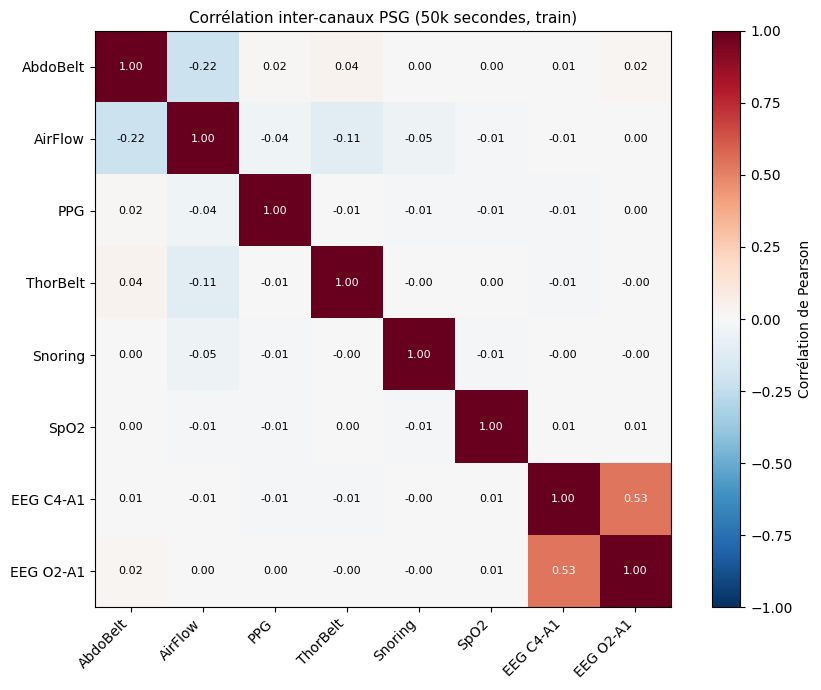

In [28]:
# ── Matrice de corrélation inter-canaux ───────────────────────────────────────
# On calcule la corrélation sur les moyennes par seconde
X_sec_flat = X_sec.reshape(-1, N_SIGNALS)   # (4400*90, 8)

rng3 = np.random.default_rng(RANDOM_SEED)
sample_idx = rng3.choice(len(X_sec_flat), size=50000, replace=False)
corr_matrix = np.corrcoef(X_sec_flat[sample_idx].T)   # (8, 8)

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, label='Corrélation de Pearson')
ax.set_xticks(range(N_SIGNALS))
ax.set_yticks(range(N_SIGNALS))
ax.set_xticklabels(SIGNAL_NAMES, rotation=45, ha='right')
ax.set_yticklabels(SIGNAL_NAMES)
ax.set_title('Corrélation inter-canaux PSG (50k secondes, train)', fontsize=11)

# Annotations des valeurs
for i in range(N_SIGNALS):
    for j in range(N_SIGNALS):
        val = corr_matrix[i, j]
        color = 'white' if abs(val) > 0.5 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=8, color=color)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig_07_correlation_matrix.png', dpi=100, bbox_inches='tight')
plt.show()


---

## 12. Biais positionnel — les apnées sont-elles distribuées uniformément ?

On vérifie si les apnées ont tendance à apparaître plutôt au début, au milieu
ou à la fin de la fenêtre de 90 secondes. Un biais positionnel indiquerait
que le modèle pourrait exploiter la position temporelle plutôt que le signal.


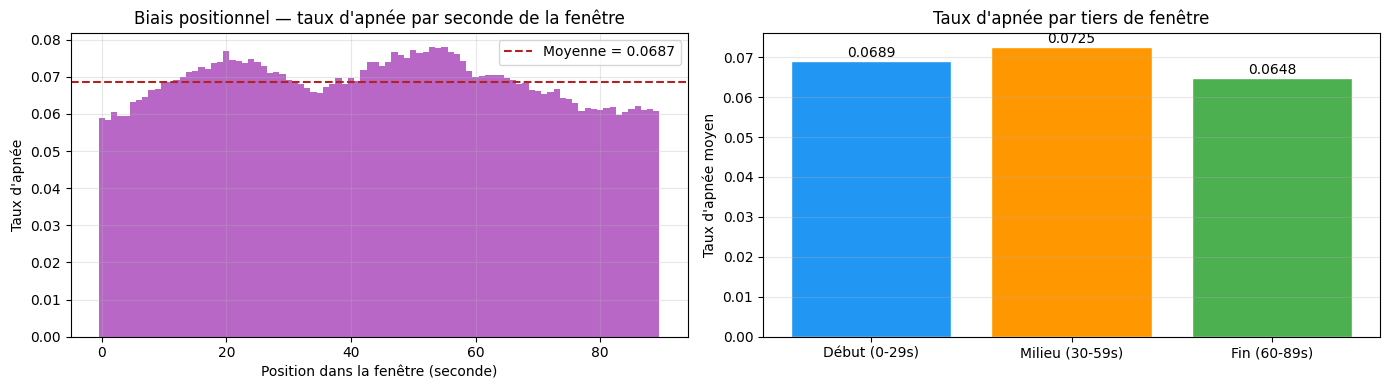

Coefficient de variation (CV) : 0.079
CV < 0.2 → distribution quasi-uniforme (pas de biais positionnel significatif)


In [34]:
# ── Distribution temporelle des apnées dans la fenêtre ───────────────────────
apnea_by_position = Y_all.mean(axis=0)   # (90,) — taux d'apnée à chaque seconde

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Position dans la fenêtre
ax = axes[0]
ax.bar(range(N_LABEL_COLS), apnea_by_position, color='#9C27B0', alpha=0.7, width=1.0)
ax.axhline(apnea_by_position.mean(), color='firebrick', linestyle='--',
           label=f'Moyenne = {apnea_by_position.mean():.4f}')
ax.set_xlabel('Position dans la fenêtre (seconde)')
ax.set_ylabel("Taux d'apnée")
ax.set_title('Biais positionnel — taux d\'apnée par seconde de la fenêtre')
ax.legend()
ax.grid(alpha=0.3)

# Uniformité : découpage début / milieu / fin
thirds = ['Début (0-29s)', 'Milieu (30-59s)', 'Fin (60-89s)']
thirds_rates = [
    apnea_by_position[:30].mean(),
    apnea_by_position[30:60].mean(),
    apnea_by_position[60:].mean(),
]
axes[1].bar(thirds, thirds_rates, color=['#2196F3', '#FF9800', '#4CAF50'], edgecolor='white')
axes[1].set_ylabel("Taux d'apnée moyen")
axes[1].set_title('Taux d\'apnée par tiers de fenêtre')
axes[1].grid(alpha=0.3, axis='y')
for i, v in enumerate(thirds_rates):
    axes[1].text(i, v + 0.001, f'{v:.4f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig_08_positional_bias.png', dpi=100, bbox_inches='tight')
plt.show()

cv = apnea_by_position.std() / apnea_by_position.mean()
print(f'Coefficient de variation (CV) : {cv:.3f}')
print('CV < 0.2 → distribution quasi-uniforme (pas de biais positionnel significatif)' if cv < 0.2
      else 'CV > 0.2 → biais positionnel présent')


---

## 13. Structure des événements d'apnée

On analyse la durée typique des apnées et le nombre d'événements par fenêtre.
La durée minimale clinique d'une apnée est de **10 secondes**.


Événements totaux          : 1,486
Durée minimale             : 1 s
Durée maximale             : 70 s
Durée moyenne              : 18.3 s
Durée médiane              : 17.0 s
% événements ≥ 10 s        : 84.1%
Événements / fenêtre (pos) : 1.65


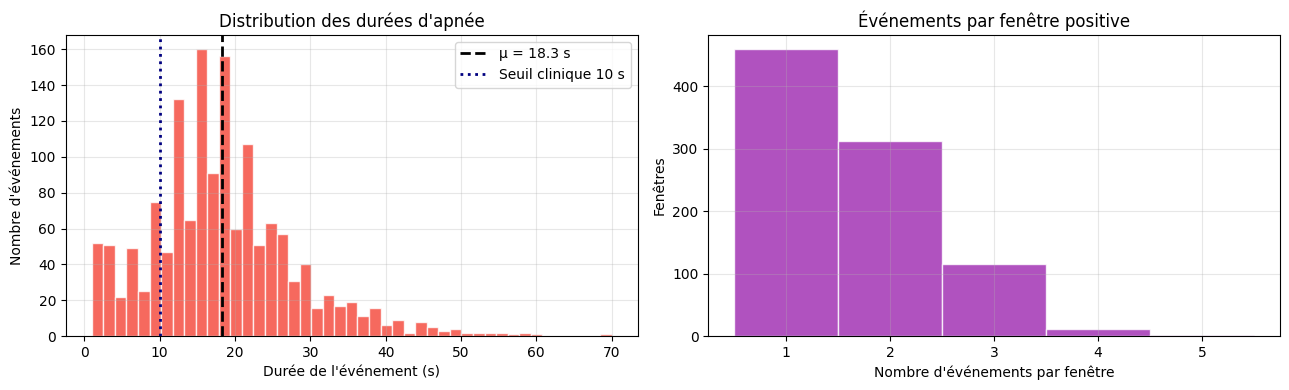

In [35]:
# ── Extraction de tous les événements ────────────────────────────────────────
def extract_events(mask):
    m = np.concatenate([[0], mask.astype(int), [0]])
    d = np.diff(m)
    return list(zip(np.where(d == 1)[0].tolist(), np.where(d == -1)[0].tolist()))

all_durations   = []
events_per_win  = []

for i in range(len(Y_all)):
    evts = extract_events(Y_all[i])
    events_per_win.append(len(evts))
    for s, e in evts:
        all_durations.append(e - s)

all_durations  = np.array(all_durations)
events_per_win = np.array(events_per_win)

print(f'Événements totaux          : {len(all_durations):,}')
print(f'Durée minimale             : {all_durations.min()} s')
print(f'Durée maximale             : {all_durations.max()} s')
print(f'Durée moyenne              : {all_durations.mean():.1f} s')
print(f'Durée médiane              : {np.median(all_durations):.1f} s')
print(f'% événements ≥ 10 s        : {(all_durations >= 10).mean()*100:.1f}%')
print(f'Événements / fenêtre (pos) : {events_per_win[events_per_win>0].mean():.2f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(all_durations, bins=45, color='#F44336', edgecolor='white', alpha=0.8)
axes[0].axvline(all_durations.mean(), color='black', linestyle='--', linewidth=2,
                label=f'μ = {all_durations.mean():.1f} s')
axes[0].axvline(10, color='navy', linestyle=':', linewidth=2,
                label='Seuil clinique 10 s')
axes[0].set_xlabel("Durée de l'événement (s)")
axes[0].set_ylabel("Nombre d'événements")
axes[0].set_title("Distribution des durées d'apnée")
axes[0].legend(); axes[0].grid(alpha=0.3)

evts_pos = events_per_win[events_per_win > 0]
axes[1].hist(evts_pos, bins=range(1, evts_pos.max()+2), color='#9C27B0',
             edgecolor='white', alpha=0.8, align='left')
axes[1].set_xlabel("Nombre d'événements par fenêtre")
axes[1].set_ylabel('Fenêtres')
axes[1].set_title("Événements par fenêtre positive")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig_09_event_structure.png', dpi=100, bbox_inches='tight')
plt.show()


---

## 14. Résumé et conclusions pour le notebook 02

### Résultats clés

| Observation | Valeur | Implication |
|-------------|--------|-------------|
| **Déséquilibre classes** | pos_weight ≈ 13.6 | `BCEWithLogitsLoss(pos_weight=12.23)` sur train |
| **Variabilité inter-sujets** | ×37 (0.74% → 27.24%) | Split **par sujet**, pas aléatoire |
| **Durée typique apnée** | ~17 s (1700 pts @ 100Hz) | Kernels CNN k=11 (110 ms) adaptés |
| **Délai AirFlow → SpO₂** | ~15-20 s | BiLSTM nécessaire pour dépendances longues |
| **Signaux discriminants** | AirFlow, SpO₂, AbdoBelt, ThorBelt | Tous les 8 canaux utiles |
| **Biais positionnel** | CV < 0.2 | Distribution uniforme → pas de biais |
| **Fenêtres positives** | ~20% | Pas de sous-échantillonnage nécessaire |

### Ce que fait le notebook 02
1. Split train/val par sujet (`VAL_SUBJECTS = [0, 1, 8, 13, 15]`)
2. `StandardScaler` par canal (fitté sur train uniquement)
3. Calcul `pos_weight = 12.23` (split train : 17 sujets)
4. Sauvegarde des `.npy` pour `mmap_mode='r'` dans le notebook 03
